Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

CSV load

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ratinopathy/data_all.csv")
print(df.head())

   Unnamed: 0                 file  cat
0           0    o_c1t10003118.jpg    1
1           1  o_c1t1003016260.jpg    1
2           2  o_c1t1004522299.jpg    1
3           3  o_c1t1008823172.jpg    1
4           4  o_c1t1011431188.jpg    1


Image load function

In [ ]:
def load_images(df, img_dir, img_size=224):
    images = []
    labels = []

    for index, row in df.iterrows():
        img_path = os.path.join(img_dir, row['file']) # Changed 'image_id' to 'file'

        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_size, img_size))

        images.append(img)
        labels.append(row['cat']) # Changed 'label' to 'cat'

    return np.array(images), np.array(labels)

Load dataset

In [ ]:
X, y = load_images(df, "/content/drive/MyDrive/Colab Notebooks/ratinopathy/images")

Normalize

In [ ]:
X = X / 255.0

Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Check shape

In [ ]:
print(X_train.shape)
print(y_train.shape)

(1411, 224, 224, 3)
(1411,)


Autoencoder Model

In [ ]:
input_img = Input(shape=(224, 224, 3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(128, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer='adam',
    loss='mse'
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,955 (1.27 MB)

 Trainable params: 333,955 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Train Autoencoder

In [ ]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, X_test)
)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 298ms/step - loss: 0.0269 - val_loss: 0.0055
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0041 - val_loss: 0.0027
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - loss: 0.0022 - val_loss: 0.0019
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.0017 - val_loss: 0.0014
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 123ms/step - loss: 0.0014 - val_loss: 0.0011
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 8.8188e-04 - val_loss: 0.0012
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - loss: 7.8926e-04 - val_loss: 6.8427e-04
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - loss: 7.2385e-04 - val_loss: 8.3626e-04
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - loss: 7.5339e-04 - val_loss: 6.8388e-04
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 6.3025e-04 - val_loss: 5.7253e-04
Epoch 12/20
45

Reconstructed Images

In [ ]:
X_test_clean = autoencoder.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step


Visualization (Before vs After)

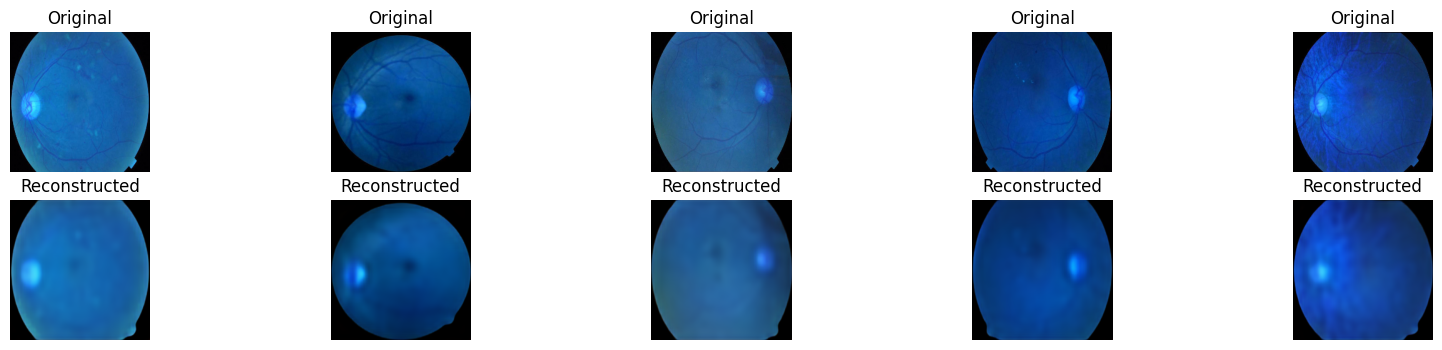

In [ ]:
n = 5 # Number of images to display
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis("off")

    # Reconstructed Image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(X_test_clean[i])
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

Denoised image generate

In [ ]:
X_train_claen=autoencoder.predict(X_train)
X_test_clean=autoencoder.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


Encoder (Feature Extraction)

In [ ]:
encoder = Model(input_img, encoded)

X_train_encoded = encoder.predict(X_train)
X_test_encoded = encoder.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


In [ ]:
def load_images(df, img_dir, img_size=224):
    images = []
    labels = []

    for index, row in df.iterrows():
        img_path = os.path.join(img_dir, row['file'])

        img = cv2.imread(img_path)
        img = cv2.resize(img, (img_size, img_size))

        images.append(img)
        labels.append(row['cat'])

    return np.array(images), np.array(labels)

In [ ]:
X, y = load_images(df, "/content/drive/MyDrive/Colab Notebooks/ratinopathy/images")

In [ ]:
X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(3, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 183ms/step - accuracy: 0.6364 - loss: 1.0823 - val_accuracy: 0.6487 - val_loss: 0.7104
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.6953 - loss: 0.7971 - val_accuracy: 0.6657 - val_loss: 0.6652
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.7045 - loss: 0.7715 - val_accuracy: 0.6572 - val_loss: 0.8115
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.7009 - loss: 0.7874 - val_accuracy: 0.6997 - val_loss: 0.6346
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.7257 - loss: 0.7149 - val_accuracy: 0.6912 - val_loss: 0.6161
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.7293 - loss: 0.7019 - val_accuracy: 0.7110 - val_loss: 0.5907
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7413 - loss: 0.6910 - val_accuracy: 0.6941 - val_loss: 0.6007
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.7342 - loss: 0.7008 - val_accuracy: 0.6912 -

In [ ]:
print("CNN Accuracy:", cnn_model.evaluate(X_test, y_test)[1])


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7507 - loss: 1.5937
CNN Accuracy: 0.7507082223892212


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred =cnn_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step
[[150  11   1]
 [  8  82  19]
 [  3  46  33]]
              precision    recall  f1-score   support

           1       0.93      0.93      0.93       162
           2       0.59      0.75      0.66       109
           3       0.62      0.40      0.49        82

    accuracy                           0.75       353
   macro avg       0.71      0.69      0.69       353
weighted avg       0.75      0.75      0.74       353



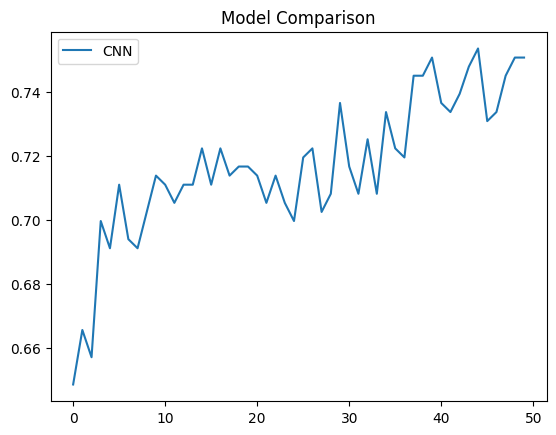

In [ ]:
plt.plot(history_cnn.history['val_accuracy'], label='CNN')


plt.legend()
plt.title("Model Comparison")
plt.show()

PRETRAINED MODEL (Load EffecientNet)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Add custom classifier

In [ ]:
num_classes = len(np.unique(y))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

Compile

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),   # low LR = stable training
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

Train model

In [ ]:
from tensorflow.keras.utils import to_categorical

# Adjust labels to be 0-indexed
y_train_adjusted = y_train - 1
y_test_adjusted = y_test - 1

# One-hot encode adjusted labels
y_train_encoded = to_categorical(y_train_adjusted, num_classes=num_classes)
y_test_encoded = to_categorical(y_test_adjusted, num_classes=num_classes)

# Create generators
train_generator = train_datagen.flow(X_train, y_train_encoded, batch_size=32)
val_generator = val_datagen.flow(X_test, y_test_encoded, batch_size=32)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50
)

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 363ms/step - accuracy: 0.4600 - loss: 1.0570 - val_accuracy: 0.4589 - val_loss: 1.0612
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 388ms/step - accuracy: 0.4592 - loss: 1.0571 - val_accuracy: 0.4589 - val_loss: 1.0609
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 363ms/step - accuracy: 0.4592 - loss: 1.0586 - val_accuracy: 0.4589 - val_loss: 1.0605
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 361ms/step - accuracy: 0.4585 - loss: 1.0577 - val_accuracy: 0.4589 - val_loss: 1.0603
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 363ms/step - accuracy: 0.4592 - loss: 1.0592 - val_accuracy: 0.4589 - val_loss: 1.0597
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 16s 366ms/step - accuracy: 0.4600 - loss: 1.0581 - val_accuracy: 0.4589 - val_loss: 1.0605
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 366ms/step - accuracy: 0.4600 - loss: 1.0599 - val_accuracy: 0.4589 - val_loss: 1.0602
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 391ms/step - accuracy: 0.4600 - loss: 1.0596 - val_accu

Fine-tuning

In [ ]:
# Unfreeze last layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # VERY LOW LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.4281 - loss: 1.1051 - val_accuracy: 0.4589 - val_loss: 1.0599
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 390ms/step - accuracy: 0.4302 - loss: 1.1008 - val_accuracy: 0.4589 - val_loss: 1.0599
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 392ms/step - accuracy: 0.4316 - loss: 1.0829 - val_accuracy: 0.4589 - val_loss: 1.0607
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 390ms/step - accuracy: 0.4408 - loss: 1.0845 - val_accuracy: 0.4589 - val_loss: 1.0620
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 22s 495ms/step - accuracy: 0.4444 - loss: 1.0755 - val_accuracy: 0.4589 - val_loss: 1.0634
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 409ms/step - accuracy: 0.4366 - loss: 1.0904 - val_accuracy: 0.4589 - val_loss: 1.0649
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 384ms/step - accuracy: 0.4231 - loss: 1.0802 - val_accuracy: 0.4589 - val_loss: 1.0679
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 392ms/step - accuracy: 0.4500 - loss: 1.0809 - val_accurac

In [ ]:
print('EfficientNet Accuracy:', model.evaluate(val_generator)[1])

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.4589 - loss: 1.0645
EfficientNet Accuracy: 0.4589235186576843
